**Note**

- could not broadcast input array from shape (165,414) into shape (165,414,3) 
- loss roi
- TBB Warning: Exact exception propagation is requested by application but the linked library is built without support for it  Down range solution

In [1]:
import os
import cv2
import sys
import copy
import random
import paddle
import paddleocr
import numpy as np
import matplotlib.pyplot as plt
from circle_fit import taubinSVD
from openvino.runtime import Core,Dimension
from pre_post_processing import *

# parameters
PADDING=60
BOX_NUM=40
OFFSET=30
FLAGS=cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
R_MAX=4000
MIN_POINTS=200
R_OFFSET=250
Y_OFFSET=20
SHRINK=50

def boost_contrast(img):
    lab= cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel, a, b = cv2.split(lab)

    # Applying CLAHE to L-channel
    # feel free to try different values for the limit and grid size:
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l_channel)

    # merge the CLAHE enhanced L-channel with the a and b channel
    limg = cv2.merge((cl,a,b))

    # Converting image from LAB Color model to BGR color spcae
    out = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    return out

#Preprocessing image functions for text detection and recognition
def image_preprocess(input_image, size):
    img = cv2.resize(input_image, (size,size))
    img = np.transpose(img, [2,0,1]) / 255
    img = np.expand_dims(img, 0)
    ##NormalizeImage: {mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225], is_scale: True}
    img_mean = np.array([0.485, 0.456,0.406]).reshape((3,1,1))
    img_std = np.array([0.229, 0.224, 0.225]).reshape((3,1,1))
    img -= img_mean
    img /= img_std
    return img.astype(np.float32)

#Preprocess for Paddle Recognition
def resize_norm_img(img, max_wh_ratio):
        no=48
        rec_image_shape = [3,no, 320] #[3, 32, 320]
        imgC, imgH, imgW = rec_image_shape
        assert imgC == img.shape[2]
        character_type = "ch"
        if character_type == "ch":
            imgW = int((no * max_wh_ratio))
        h, w = img.shape[:2]
        ratio = w / float(h)
        if math.ceil(imgH * ratio) > imgW:
            resized_w = imgW
        else:
            resized_w = int(math.ceil(imgH * ratio))
        resized_image = cv2.resize(img, (resized_w, imgH))
        resized_image = resized_image.astype('float32')
        resized_image = resized_image.transpose((2, 0, 1)) / 255
        resized_image -= 0.5
        resized_image /= 0.5
        padding_im = np.zeros((imgC, imgH, imgW), dtype=np.float32)
        padding_im[:, :, 0:resized_w] = resized_image
        return padding_im
    
def rotateAndScale(img, scaleFactor = 0.5, degreesCCW = 30):
    '''
    rotate image with no cut out vertices
    Args:
        img: original image
        scaleFactor: scale of output image
        degreesCCW: angle (degrees)
    Return:
        rotateImg: rotated image
        M: rotate matrix
    '''
    h,w,c = img.shape #note: numpy uses (y,x) convention but most OpenCV functions use (x,y)
    M = cv2.getRotationMatrix2D(center=(w/2,h/2), angle=degreesCCW, scale=scaleFactor) #rotate about center of image.

    #choose a new image size.
    new_w,new_h = w*scaleFactor,h*scaleFactor
    #include this if you want to prevent corners being cut off
    r = np.deg2rad(degreesCCW)
    new_w,new_h = (abs(np.sin(r)*new_h) + abs(np.cos(r)*new_w),abs(np.sin(r)*new_w) + abs(np.cos(r)*new_h))

    #the warpAffine function call, below, basically works like this:
    # 1. apply the M transformation on each pixel of the original image
    # 2. save everything that falls within the upper-left "dsize" portion of the resulting image.

    #So I will find the translation that moves the result to the center of that region.
    (tx,ty) = ((new_w-w)/2,(new_h-h)/2)
    M[0,2] += tx #third column of matrix holds translation, which takes effect after rotation.
    M[1,2] += ty

    rotatedImg = cv2.warpAffine(img, M, dsize=(int(new_w),int(new_h)))
    return rotatedImg,M

def calc_dist(pt1,pt2):
    '''
    Calculate distance of 2 point
    Args:
        pt1: first point
        pt2: second point
    Return:
        dist: distance
    '''
    dist = cv2.norm(pt1-pt2)
    return dist

def infer_circle(mask):
    '''
    Infer centerpoint, radius of curve
    Args:
        mask: mask of curve image (BGR)
    Return:
        xc: x cord of center point
        yc: y cord of center point
        r: radius
        sigma: sigma
    '''
    # convert image to grayscale
    mask = cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY)
    h,w = mask.shape
    # get first point in mask
    curve = []
    for i in range(w):
        v_line = mask[:,i:i+1]
        pos = cv2.findNonZero(v_line)
        if pos is not None:
            curve.append((pos[0][0][1],i))
    # infer circle by taubinSVD
    xc,yc,r,sigma = taubinSVD(curve)
    return xc,yc,r,sigma

def warp_img(mask,roi):
    '''
    warp cropped image
    Args:
        mask: mask of cropped image
        roi: cropped image
    return:
        out: warpped image
        out_180: rotated 180 warpped image
    '''
    # avoid could not broadcast input array from shape (1539,2465,3) into shape (1539,86,3)
    try: 
        padding = 20
        
        mask = cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY)
        h,w = mask.shape

        curve = []
        for i in range(w):
            v_line = mask[:,i:i+1]
            pos = cv2.findNonZero(v_line)
            if pos is not None:
                curve.append((pos[0][0][1],i))

        xc, yc, r, sigma = taubinSVD(curve)

        if r < R_MAX and len(curve) > MIN_POINTS:

            r = int(r) # can not convert inifity

            if xc<0:
                x = int(r - w/2)
                y = 2*r-h
                x2 = x+w
                y2 = 2*r
            else:
                x = int(r - w/2)
                y = 0
                x2 = x+w
                y2 = h

            blank = np.zeros((r*2,r*2,3))
            blank = blank.astype(np.uint8)
            blank[y:y2,x:x2]= roi

            polar_img = cv2.warpPolar(blank,(0,0),(r,r+Y_OFFSET),r+R_OFFSET,FLAGS)
            out = polar_img.transpose(1,0,2)[::-1]

            gray = cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)
            ret, thresh = cv2.threshold(gray, 127, 255, 0)
            contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            areas = []
            for cnt in contours:
                area = cv2.contourArea(cnt)
                areas.append(area)

            cnt_max = contours[np.argmax(areas)]
            xr,yr,w,h = cv2.boundingRect(cnt_max)

            x0=xr-padding
            y0=yr-padding
            x1=xr+w+padding
            y1=yr+h+padding

            out = out[y0:y1,x0:x1]
        else:
            out = roi

        # check zero-dim after warp
        h,w,c = out.shape
        if h*w*c==0:
            out=roi
    
    except Exception as e:
        print(e)
        out = roi
        
    # revert image
    #out = cv2.bitwise_not(out)
    # rotate image
    out_180 = cv2.rotate(out,cv2.ROTATE_180)
    
    return out,out_180

class Extractor:
    def __init__(self):
        self.res=1280 # the resolution range 1280,2560,5120,... TB warnning
        self.det_compiled_model = None
        self.rec_compiled_model = None
        self.det_input_layer = None # input and nodes for text detection
        self.det_output_layer = None # output nodes for text detection
        self.rec_input_layer = None # input and nodes for text recognition
        self.rec_output_layer = None # output nodes for text recognition
        self.PADDING = 60 # roi padding
        self.BOX_NUM = 40 # maximum box number
        self.OFFSET = 30
        self.FLAGS = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
        self.R_MAX = 3000
        self.MIN_POINTS = 300
        self.R_OFFSET=250
        self.Y_OFFSET=20
        self.SHRINK = 50
    
    def load_model(self,det_model_dir="paddle_ocr/ch_PP-OCRv3_det_infer",
                   rec_model_dir = "paddle_ocr/ch_PP-OCRv3_rec_infer"):
        '''
        Load detection and recognition model
        Args:
            det_model_dir: detection inference model (pretrained)
            rec_model_dir: recognition inference model (pretrained)
        Return:
        Load model into self.det_compiled_model,self.rec_compiled_model
        '''
        #Load Network text detection
        det_model_file_path = det_model_dir + "/inference.pdmodel"
        det_params_file_path = det_model_dir + "/inference.pdiparams"
        
        # initialize inference engine for text detection
        det_ie = Core()
        det_net = det_ie.read_model(model=det_model_file_path, weights=det_params_file_path)
        self.det_compiled_model = det_ie.compile_model(model=det_net, device_name="CPU")
        
        self.det_input_layer = next(iter(self.det_compiled_model.inputs)) ## get input and output nodes for text detection
        self.det_output_layer = next(iter(self.det_compiled_model.outputs))
        
        #Load the Network for Text Recognition
        rec_model_file_path = rec_model_dir + "/inference.pdmodel"
        rec_params_file_path = rec_model_dir + "/inference.pdiparams"

        # Initialize the Paddle recognition inference on CPU
        rec_ie = Core()
        # read the model and corresponding weights from file
        rec_net = rec_ie.read_model(model=rec_model_file_path, weights=rec_params_file_path)

        # assign dynamic shapes to every input layer on the last dimension
        for input_layer in rec_net.inputs:
            input_shape = input_layer.partial_shape
            input_shape[3] = Dimension(-1)
            rec_net.reshape({input_layer: input_shape})
        self.rec_compiled_model = rec_ie.compile_model(model=rec_net, device_name="CPU")
        
        # get input and output nodes
        self.rec_input_layer = next(iter(self.rec_compiled_model.inputs))
        self.rec_output_layer = next(iter(self.rec_compiled_model.outputs))
        
    def read_image(self,img_path):
        '''
        Read the image
        Args:
            img_path: image path
        Return:
            image_file: scaled image
            test_image: preprocessed array of image
        '''
        # read the image
        image = cv2.imread(img_path)
        res= self.res

        # if frame larger than full HD, reduce size to improve the performance
        scale = res/max(image.shape)

        if scale < 1:
            # resize image
            image = cv2.resize(src=image, dsize=None, fx=scale, fy=scale,interpolation=cv2.INTER_AREA)
            
        image_file = image
        test_image = image_preprocess(image_file,self.res)
        return image_file,test_image
    
    def detect(self,image_file,test_image):
        '''
        Extract roi (text regions)
        Args:
            image_file:
            test_image:
        Return:
            dt_boxes: list of detected boxes,example: [(4,2),(4,2),...] 
            mask: binary mask of image
        '''
        # Create dectect infer request
        det_request = self.det_compiled_model.create_infer_request()

        #perform the inference step
        det_request.infer(inputs = {self.det_input_layer.any_name: test_image})
        det_results = det_request.get_tensor(self.det_output_layer).data
        
        # Postprocessing for Paddle Detection
        ori_im = image_file.copy()
        data = {'image': image_file}
        data_resize = DetResizeForTest(data)
        data_norm = NormalizeImage(data_resize)
        data_list = []
        keep_keys =  ['image', 'shape']
        
        for key in keep_keys:
            data_list.append(data_resize[key]) #
        img, shape_list = data_list
        shape_list = np.expand_dims(shape_list, axis=0)
        pred = det_results[0]
        
        if isinstance(pred, paddle.Tensor):
            pred = pred.numpy()
        segmentation = pred > 0.3
        boxes_batch = []
        
        for batch_index in range(pred.shape[0]):
            src_h, src_w, ratio_h, ratio_w = shape_list[batch_index]
            mask = segmentation[batch_index]
            boxes, scores = boxes_from_bitmap(pred[batch_index], mask,src_w, src_h) # boxes (n, 4, 2), scores list of coff
            boxes_batch.append({'points': boxes})
        post_result = boxes_batch # list of {'points':[[]]}
        dt_boxes = post_result[0]['points'] # (n,4,2)
        dt_boxes = filter_tag_det_res(dt_boxes, ori_im.shape)
        
        #Preprocess detection results for recognition
        dt_boxes = sorted_boxes(dt_boxes)
        return dt_boxes,mask
    
    def crop(self,image_file,test_image):
        '''
        Extract copped roi
        Args:
            image_file:
            test_image:
        Return:
            img_crop_list: list of preprocessed image
        '''
        rois = []
        masks = []
        regs =[] # maximum rec
        boxs = [] # minimum rec 4-point 
        rects = [] # minimum rec
        slopes = [] # degree
        img_crop_list = []

        dt_boxes,mask = self.detect(image_file,test_image)
        image = cv2.resize(image_file,(self.res,self.res))
        
        # find contours
        contours, hierarchy = cv2.findContours(mask.astype("uint8"),cv2.RETR_TREE,
                                               cv2.CHAIN_APPROX_SIMPLE)

        # select suitable area
        areas = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            areas.append(area)

        # select suitable area
        cnts = []
        s_min = np.array(areas).mean()
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area > s_min:
                cnts.append(cnt)

        merged = cv2.merge([mask.astype("uint8"),mask.astype("uint8"),mask.astype("uint8")]) *255
        draw_img = merged.copy()

        for i,cnt in enumerate(cnts):
            # maximum rect
            x_m,y_m,w_m,h_m = cv2.boundingRect(cnt)
            regs.append((x_m,y_m,w_m,h_m))

            # roated rect (minimum rect)
            rect = cv2.minAreaRect(cnt)

            # angles of minrect
            slope = rect[-1]
            slopes.append(slope)

            # new rect add padding
            h = int(rect[1][0]+ self.PADDING)
            w = int(rect[1][1]+ self.PADDING)
            new_rect = (rect[0],(h,w),slope) #h,w
            rects.append(new_rect)
            box = cv2.boxPoints(new_rect)
            box = np.int0(box)
            boxs.append(box)

        if len(boxs) < self.BOX_NUM:
            for i,t in enumerate(slopes):
                # original input
                img = image.copy()
                img_mask = merged.copy()
                rect = rects[i]
                box = boxs[i] # 4 pts form of rect
                rebox = box.reshape(-1,1,2)
                #rotate
                img,M = rotateAndScale(img, scaleFactor = 2.0, degreesCCW = t)
                img_mask,_ = rotateAndScale(img_mask, scaleFactor = 2.0, degreesCCW = t)
                rebox = cv2.transform(rebox, M) # what you need
                # find new top left,bottom right
                dist = []
                for pt in rebox.reshape(-1,2):
                    d = calc_dist(np.array([0,0]),pt)
                    dist.append(d)
                top_left = rebox.reshape(-1,2)[np.argmin(dist)]
                bottom_right = rebox.reshape(-1,2)[np.argmax(dist)]
                w,h = bottom_right - top_left
                x,y = top_left
                # roi of original and mask
                out = img[y:y+h,x:x+w]
                # zero dim
                if(out.shape[0]*out.shape[1]==0):
                    continue
                out_m = img_mask[y:y+h,x:x+w]
                rois.append(out)
                masks.append(out_m)

        else:
            for i,_ in enumerate(boxs):
                # original input
                img = image.copy()
                img_mask = merged.copy()
                # read rec
                x,y,w,h = regs[i]
                x = x - self.PADDING if x - self.PADDING > 0 else 0
                y = y - self.PADDING if y - self.PADDING > 0 else 0
                # roi of original and mask
                out = img[y:y+h+self.PADDING,x:x+w+self.PADDING]
                # zero dim
                if(out.shape[0]*out.shape[1]==0):
                    continue
                out_m = img_mask[y:y+h,x:x+w]
                rois.append(boost_contrast(out))
                masks.append(out_m)

        # rotate
        if len(rois) >0:
            for i,roi in enumerate(rois):
                h,w,c = roi.shape
                if h > w:
                    rois[i] = cv2.rotate(rois[i],cv2.ROTATE_90_CLOCKWISE)
                    masks[i] = cv2.rotate(masks[i],cv2.ROTATE_90_CLOCKWISE)
        else:
            pass
        
        # warp cropped image
        for i in range(len(rois)):
            out,out_180 = warp_img(masks[i],rois[i])
            img_crop_list.append(out)
            img_crop_list.append(out_180)
        
        return img_crop_list
    
    def recognize_img(self):
        pass
    
    def recognize(self,img_crop_list):
        '''
        '''
        #Recognition starts from here
        img_num = len(img_crop_list)

        # Calculate the aspect ratio of all text bars
        width_list = []
        for img in img_crop_list:
            width_list.append(img.shape[1] / float(img.shape[0]))

        # Sorting can speed up the recognition process
        indices = np.argsort(np.array(width_list))
        rec_res = [['', 0.0]] * img_num
        batch_num = 2
        rec_processing_times = 0

        #For each detected text box, run inference for text recognition
        for beg_img_no in range(0, img_num, batch_num):
            end_img_no = min(img_num, beg_img_no + batch_num)

            norm_img_batch = []
            max_wh_ratio = 0
            for ino in range(beg_img_no, end_img_no):
                h, w = img_crop_list[indices[ino]].shape[0:2]
                wh_ratio = w * 1.0 / h
                max_wh_ratio = max(max_wh_ratio, wh_ratio)
            for ino in range(beg_img_no, end_img_no):
                norm_img = resize_norm_img(img_crop_list[indices[ino]],max_wh_ratio)
                norm_img = norm_img[np.newaxis, :]
                norm_img_batch.append(norm_img)

            norm_img_batch = np.concatenate(norm_img_batch)
            norm_img_batch = norm_img_batch.copy()

            #Run inference for text recognition
            #rec_results = self.rec_compiled_model([norm_img_batch])[self.rec_compiled_model.output(0)]
            rec_request = self.rec_compiled_model.create_infer_request()
            rec_request.infer(inputs={self.rec_input_layer.any_name: norm_img_batch})
            rec_results = rec_request.get_tensor(self.rec_output_layer).data
            preds = rec_results #(6, 47, 6625)

            #Postprocessing recognition results
            postprocess_op = build_post_process(postprocess_params)
            rec_result = postprocess_op(preds)
            for rno in range(len(rec_result)):
                rec_res[indices[beg_img_no + rno]] = rec_result[rno]
        return rec_res
    
    def infer(self,img_path):
        '''
        Inference text detection and tex recognition
        Args:
            img_path: image path
        Return:
        '''
        # Read the image
        image_file,test_image=self.read_image(img_path)
        ori_im = image_file.copy()
        
        # text detection
        dt_boxes,_ = self.detect(image_file,test_image)
        
        img_crop_list = []   
        rec_res=None
        draw_img=None
        if dt_boxes != []:
            for bno in range(len(dt_boxes)):
                tmp_box = copy.deepcopy(dt_boxes[bno])
                img_crop = get_rotate_crop_image(ori_im, tmp_box)
                img_crop_list.append(img_crop)
                
            #Recognition starts from here
            img_num = len(img_crop_list)

            # Calculate the aspect ratio of all text bars
            width_list = []
            for img in img_crop_list:
                width_list.append(img.shape[1] / float(img.shape[0]))
            
            # Sorting can speed up the recognition process
            indices = np.argsort(np.array(width_list))
            rec_res = [['', 0.0]] * img_num
            batch_num = 6

            #For each detected text box, run inference for text recognition
            for beg_img_no in range(0, img_num, batch_num):
                end_img_no = min(img_num, beg_img_no + batch_num)

                norm_img_batch = []
                max_wh_ratio = 0
                for ino in range(beg_img_no, end_img_no):
                    h, w = img_crop_list[indices[ino]].shape[0:2]
                    wh_ratio = w * 1.0 / h
                    max_wh_ratio = max(max_wh_ratio, wh_ratio)
                for ino in range(beg_img_no, end_img_no):
                    norm_img = resize_norm_img(img_crop_list[indices[ino]],max_wh_ratio)
                    norm_img = norm_img[np.newaxis, :]
                    norm_img_batch.append(norm_img)

                norm_img_batch = np.concatenate(norm_img_batch)
                norm_img_batch = norm_img_batch.copy()

                #Run inference for text recognition
                rec_request = self.rec_compiled_model.create_infer_request()
                rec_request.infer(inputs={self.rec_input_layer.any_name: norm_img_batch})
                rec_results = rec_request.get_tensor(self.rec_output_layer).data
                preds = rec_results

                #Postprocessing recognition results
                postprocess_op = build_post_process(postprocess_params)
                rec_result = postprocess_op(preds)
                for rno in range(len(rec_result)):
                    rec_res[indices[beg_img_no + rno]] = rec_result[rno]

                #Text recognition results, rec_res, include two parts:
                #txts are the recognized text results, scores are the recognition confidence level                   
                if rec_res != []:
                    img = Image.fromarray(cv2.cvtColor(image_file, cv2.COLOR_BGR2RGB))
                    boxes = dt_boxes
                    txts = [rec_res[i][0] for i in range(len(rec_res))] 
                    scores = [rec_res[i][1] for i in range(len(rec_res))]

                    #draw text recognition results beside the image
                    # remove pred samller than drop_score
                    draw_img = draw_ocr_box_txt(img,boxes,txts,scores,drop_score=0.2)
        
        
        return rec_res,draw_img

In [12]:
extractor = Extractor()
extractor.load_model()

extractor.res = 2

#img_name="samples/Google Nest Audio.jpg"
#img_name = os.path.join("samples",random.choice(os.listdir("samples")))
img_name = os.path.join("samples/Google Nest Audio.jpg")
print(img_name)

image_file,test_image=extractor.read_image(img_name)

# crop images
img_crop_list = extractor.crop(image_file,test_image)

rec_res = extractor.recognize(img_crop_list)
print(f"rec_res (recognize): {len(rec_res)}")

# plot roi
fig, axes = plt.subplots(nrows=len(img_crop_list), ncols=1, figsize=(20,60))
plt.subplots_adjust(left=0.1,bottom=0.1,right=0.9,top=0.9,wspace=0.4,hspace=0.8)
for i in range(len(img_crop_list)):
    axes[i].imshow(img_crop_list[i])
    axes[i].set_title(f'[{i}] {rec_res[i]}', fontsize =10)

samples/Google Nest Audio.jpg


TBB Warning: Exact exception propagation is requested by application but the linked library is built without support for it


RuntimeError: Shape inference of AvgPool node with name pool2d_5.tmp_0 failed: Check 'window_dilated_dim <= data_padded_dilated_dim' failed at src/core/src/validation_util.cpp:176:
While validating node 'v1::AvgPool AvgPool_294360 (Parameter_294359[0]:f32[2,512,3,1]) -> (f32[64,512,1,32])' with friendly_name 'AvgPool_294360':
Window after dilation has dimension (dim: 2) larger than the data shape after padding (dim: 1) at axis 1.


In [8]:
cv2.imwrite("crop.jpg",img_crop_list[6])

True

# infer

rec_res (infer): 3
('G', 0.99387157)
('TEE358912', 0.9070181)
('SetupCode:3DS2XUKR', 0.9309652)


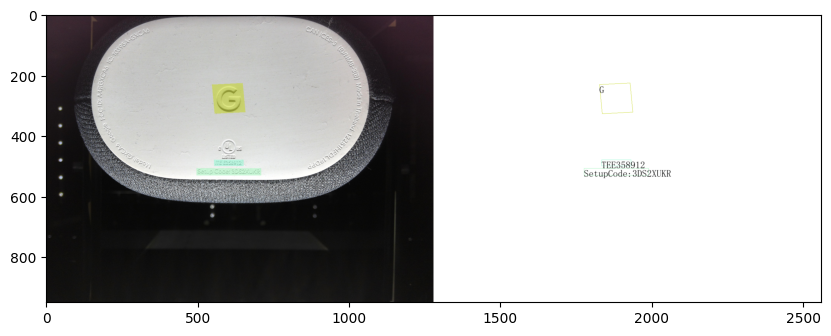

In [11]:
rec_res,draw_img=extractor.infer(img_name)
print(f"rec_res (infer): {len(rec_res)}")

for r in rec_res:
    print(r)
    
if rec_res:
    plt.figure(figsize=(10,10))
    plt.imshow(draw_img)

# text recognition

In [ ]:
extractor = Extractor()
extractor.load_model()

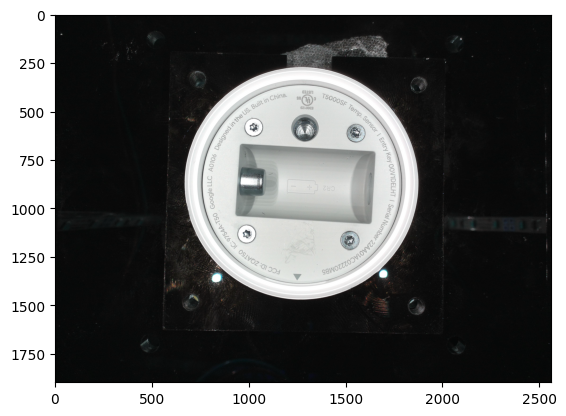

In [14]:
image_file,test_image=extractor.read_image(os.path.join("samples",random.choice(os.listdir("samples"))))
#image_file,test_image=extractor.read_image("samples/Google Nest Audio.jpg")

# crop images
img_crop_list = extractor.crop(image_file,test_image)

plt.imshow(image_file)

In [6]:
#Load the Network for Text Recognition
rec_model_dir = "paddle_ocr/ch_PP-OCRv3_rec_infer"
rec_model_file_path = rec_model_dir + "/inference.pdmodel"
rec_params_file_path = rec_model_dir + "/inference.pdiparams"

 # Initialize the Paddle recognition inference on CPU
rec_ie = Core()
# read the model and corresponding weights from file
rec_net = rec_ie.read_model(model=rec_model_file_path, weights=rec_params_file_path)

# assign dynamic shapes to every input layer on the last dimension
for input_layer in rec_net.inputs:
    input_shape = input_layer.partial_shape
    input_shape[3] = Dimension(-1)
    rec_net.reshape({input_layer: input_shape})

rec_compiled_model = rec_ie.compile_model(model=rec_net, device_name="CPU")

# get input and output nodes
rec_input_layer = next(iter(rec_compiled_model.inputs))
rec_output_layer = next(iter(rec_compiled_model.outputs))
print(rec_input_layer)
print(rec_output_layer)

<ConstOutput: names[x] shape[?,3,48,?] type: f32>
<ConstOutput: names[softmax_5.tmp_0] shape[?,1..,6625] type: f32>


In [7]:
#if dt_boxes != []:
#Recognition starts from here
img_num = len(img_crop_list)

print(f'img_num: {img_num}')

# Calculate the aspect ratio of all text bars
width_list = []
for img in img_crop_list:
    width_list.append(img.shape[1] / float(img.shape[0]))

# Sorting can speed up the recognition process
indices = np.argsort(np.array(width_list))
rec_res = [['', 0.0]] * img_num
batch_num = 2
rec_processing_times = 0

#For each detected text box, run inference for text recognition
for beg_img_no in range(0, img_num, batch_num):
    end_img_no = min(img_num, beg_img_no + batch_num)

    norm_img_batch = []
    max_wh_ratio = 0
    for ino in range(beg_img_no, end_img_no):
        h, w = img_crop_list[indices[ino]].shape[0:2]
        wh_ratio = w * 1.0 / h
        max_wh_ratio = max(max_wh_ratio, wh_ratio)
    for ino in range(beg_img_no, end_img_no):
        norm_img = resize_norm_img(img_crop_list[indices[ino]],max_wh_ratio)
        norm_img = norm_img[np.newaxis, :]
        norm_img_batch.append(norm_img)

    norm_img_batch = np.concatenate(norm_img_batch)
    norm_img_batch = norm_img_batch.copy()

    #Run inference for text recognition
    #rec_results = rec_compiled_model([norm_img_batch])[rec_compiled_model.output(0)]
    rec_request = rec_compiled_model.create_infer_request()
    rec_request.infer(inputs={rec_input_layer.any_name: norm_img_batch})
    rec_results = rec_request.get_tensor(rec_output_layer).data
    preds = rec_results #(6, 47, 6625)
    
    #Postprocessing recognition results
    postprocess_op = build_post_process(postprocess_params)
    rec_result = postprocess_op(preds)
    for rno in range(len(rec_result)):
        rec_res[indices[beg_img_no + rno]] = rec_result[rno]
        
print(f"rec_res: {len(rec_res)}")

img_num: 24
rec_res: 24


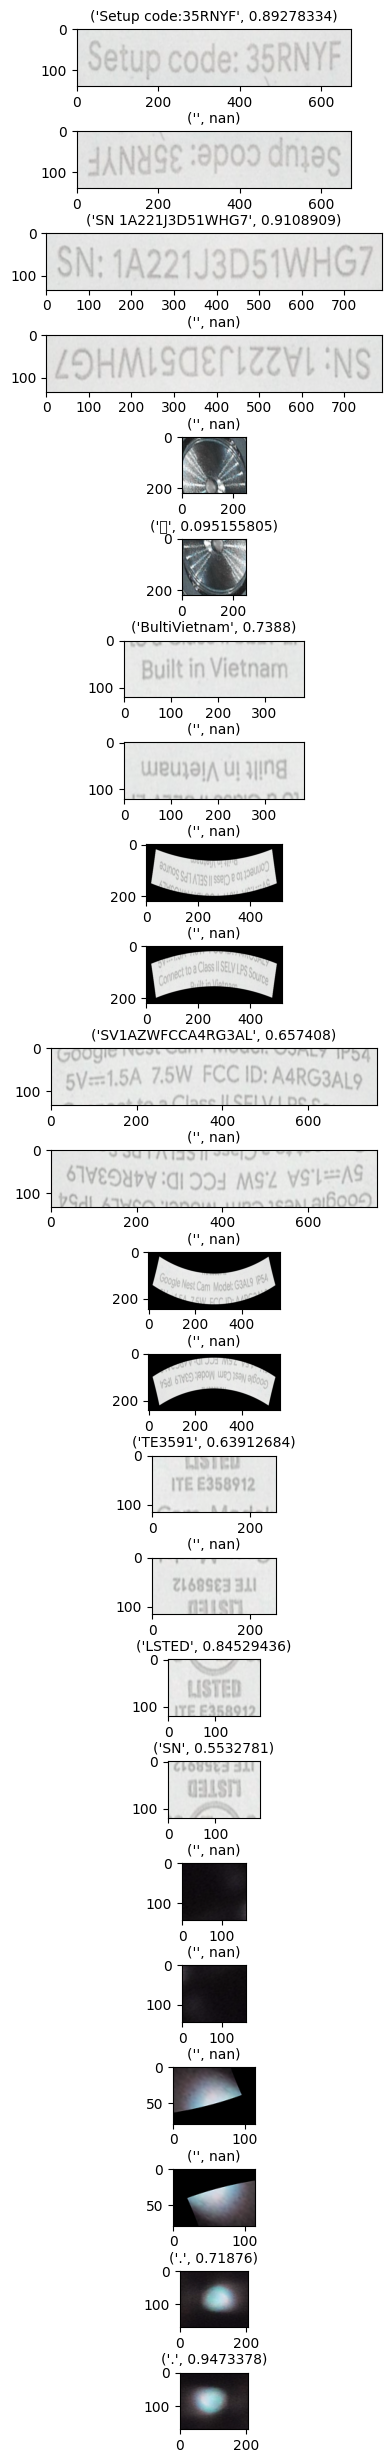

In [11]:
# plot roi
fig, axes = plt.subplots(nrows=len(img_crop_list), ncols=1, figsize=(10,30))
plt.subplots_adjust(left=0.1,bottom=0.1,right=0.9,top=0.9,wspace=0.4,hspace=0.8)
for i in range(len(img_crop_list)):
    axes[i].imshow(img_crop_list[i])
    axes[i].set_title(rec_res[i], fontsize =10)

# detect cropped image

boxs 8


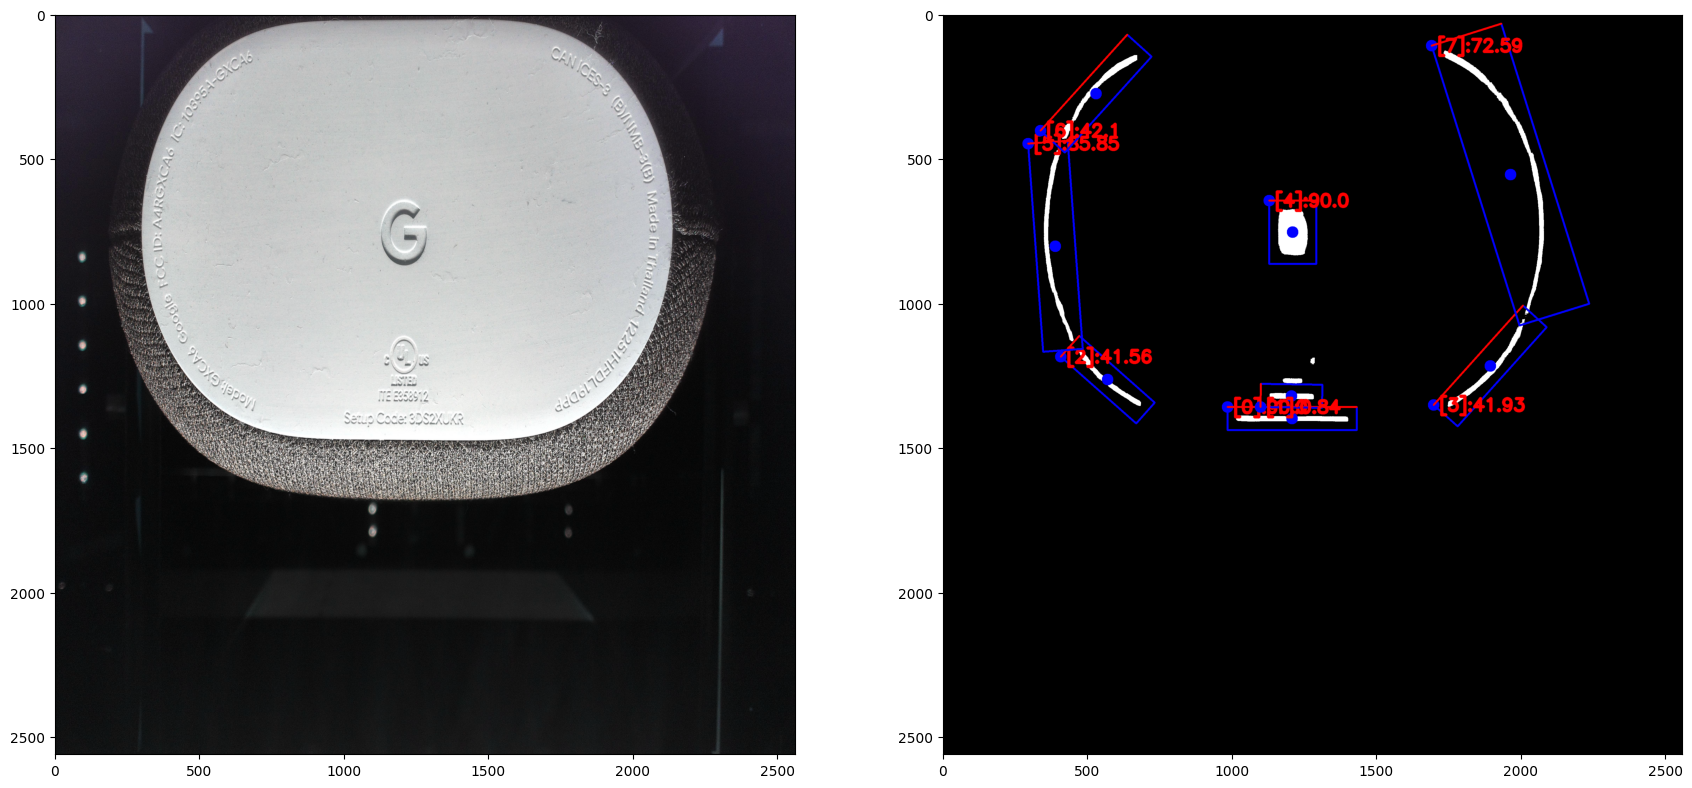

In [430]:
rois = []
masks = []
regs =[] # maximum rec
boxs = [] # minimum rec 4-point 
rects = [] # minimum rec
slopes = [] # degree

image_file,test_image=extractor.read_image(os.path.join("samples",random.choice(os.listdir("samples"))))
dt_boxes,mask = extractor.detect(image_file,test_image)
image = cv2.resize(image_file,(extractor.res,extractor.res))
# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# select suitable area
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)
    
# select suitable area
cnts = []
s_min = np.array(areas).mean()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > s_min:
        cnts.append(cnt)
        
merged = cv2.merge([mask.astype("uint8"),mask.astype("uint8"),mask.astype("uint8")]) *255
draw_img = merged.copy()

for i,cnt in enumerate(cnts):
    # maximum rect
    x_m,y_m,w_m,h_m = cv2.boundingRect(cnt)
    regs.append((x_m,y_m,w_m,h_m))
    
    # roated rect (minimum rect)
    rect = cv2.minAreaRect(cnt)
    
    # angles of minrect
    slope = rect[-1]
    slopes.append(slope)
    
    # new rect add padding
    h = int(rect[1][0]+ PADDING)
    w = int(rect[1][1]+ PADDING)
    new_rect = (rect[0],(h,w),slope) #h,w
    rects.append(new_rect)
    box = cv2.boxPoints(new_rect)
    box = np.int0(box)
    boxs.append(box)
    
    # draw
    cv2.drawContours(draw_img,[box],0,(0,0,255),6) # min rect
    cv2.circle(draw_img,(int(rect[0][0]),int(rect[0][1])),20,(0,0,255),-1)# top point
    cv2.circle(draw_img,box[0],20,(0,0,255),-1)# top point
    cv2.line(draw_img,box[0],box[1],(255,0,0),6)# top line
    cv2.putText(draw_img,f"[{i}]:{round(slope,2)}",box[0]+np.array([20,20]),
                cv2.FONT_HERSHEY_SIMPLEX,2,(255,0,0),10, cv2.LINE_AA) # angle

print(f"boxs {len(boxs)}")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(21, 12))
axes[0].imshow(image)
#axes[1].imshow(mask)
axes[1].imshow(draw_img)

if len(boxs) < BOX_NUM:
    for i,t in enumerate(slopes):
        # original input
        img = image.copy()
        img_mask = merged.copy()
        rect = rects[i]
        box = boxs[i] # 4 pts form of rect
        rebox = box.reshape(-1,1,2)
        #rotate
        img,M = rotateAndScale(img, scaleFactor = 2.0, degreesCCW = t)
        img_mask,_ = rotateAndScale(img_mask, scaleFactor = 2.0, degreesCCW = t)
        rebox = cv2.transform(rebox, M) # what you need
        # find new top left,bottom right
        dist = []
        for pt in rebox.reshape(-1,2):
            d = calc_dist(np.array([0,0]),pt)
            dist.append(d)
        top_left = rebox.reshape(-1,2)[np.argmin(dist)]
        bottom_right = rebox.reshape(-1,2)[np.argmax(dist)]
        w,h = bottom_right - top_left
        x,y = top_left
        # roi of original and mask
        out = img[y:y+h,x:x+w]
        # zero dim
        if(out.shape[0]*out.shape[1]==0):
            continue
        out_m = img_mask[y:y+h,x:x+w]
        rois.append(out)
        masks.append(out_m)

else:
    print("overloaded!")
    for i,_ in enumerate(boxs):
        # original input
        img = img_org.copy()
        img_mask = mask3.copy()
        # read rec
        x,y,w,h = mboxs[i]
        x = x - PADDING if x - PADDING > 0 else 0
        y = y - PADDING if y - PADDING > 0 else 0
        # roi of original and mask
        out = img[y:y+h+padding,x:x+w+padding]
        # zero dim
        if(out.shape[0]*out.shape[1]==0):
            continue
        out_m = img_mask[y:y+h,x:x+w]
        rois.append(out)
        masks.append(out_m)

# rotate
if len(rois) >0:
    for i,roi in enumerate(rois):
        h,w,c = roi.shape
        if h > w:
            rois[i] = cv2.rotate(rois[i],cv2.ROTATE_90_CLOCKWISE)
            masks[i] = cv2.rotate(masks[i],cv2.ROTATE_90_CLOCKWISE)
else:
    print("empty roi!")

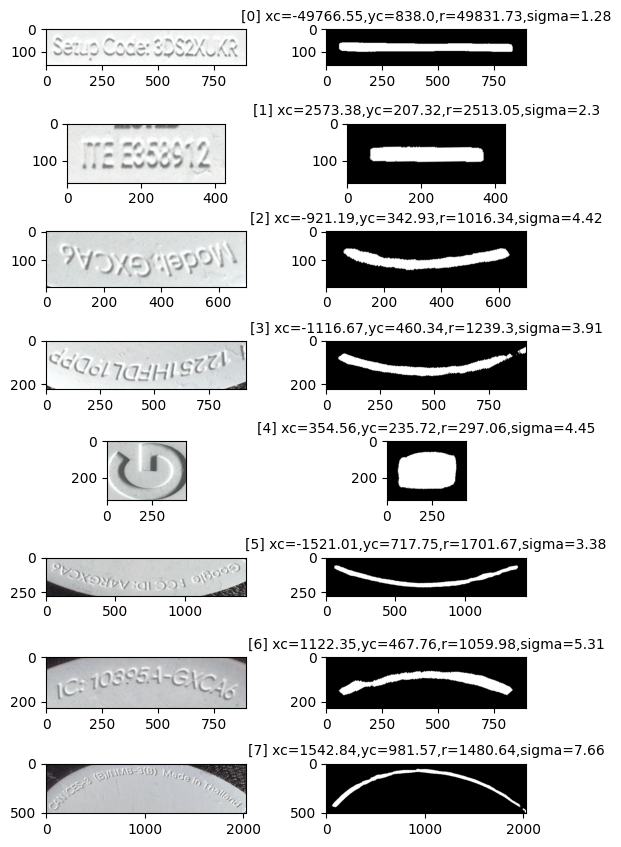

In [431]:
# plot roi
fig, axes = plt.subplots(nrows=len(rois), ncols=2, figsize=(6,10))
plt.subplots_adjust(left=0.1,bottom=0.1,right=0.9,top=0.9,wspace=0.4,hspace=0.8)
for i in range(len(rois)):
    xc,yc,r,sigma = infer_circle(masks[i])
    axes[i][0].imshow(rois[i])
    axes[i][1].imshow(masks[i])
    axes[i][1].set_title(f"[{i}] xc={round(xc,2)},yc={round(yc,2)},r={round(r,2)},sigma={round(sigma,2)}", fontsize =10)

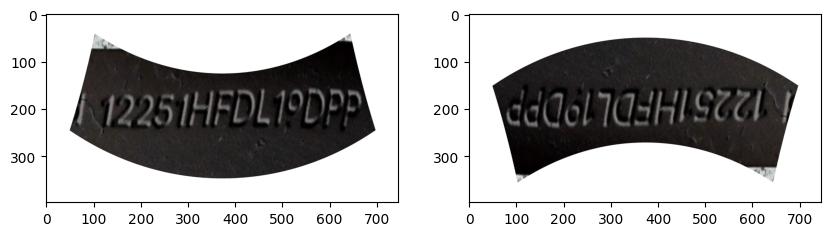

In [436]:
idx = 3

out,out_180 = warp_img(masks[idx],rois[idx])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,10))
for i in range(2):
    axes[0].imshow(out)
    axes[1].imshow(out_180)

# debug warpped image

In [402]:
mask = masks[idx]
roi = rois[idx]

(153, 779)


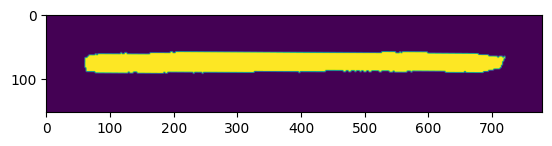

In [403]:
mask = cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY)
h,w = mask.shape
print(mask.shape)
plt.imshow(mask)

In [321]:
curve = []
for i in range(w):
    v_line = mask[:,i:i+1]
    pos = cv2.findNonZero(v_line)
    if pos is not None:
        curve.append((pos[0][0][1],i))

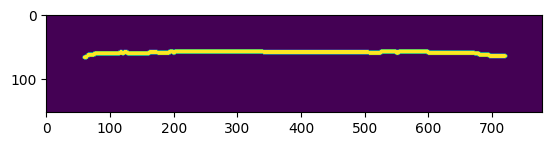

In [322]:
blank = np.zeros_like(mask)
for point in curve:
    cv2.circle(blank,(point[1], point[0]), 3, (255,255,255), -1)
plt.imshow(blank)

In [323]:
xc, yc, r, sigma = taubinSVD(curve)
r = int(r)
print(f"xc={int(xc)}, yc={int(yc)}, r={int(r)}, sigma={sigma}") #217330,1739

xc=11685, yc=377, r=11627, sigma=1.099232386190055


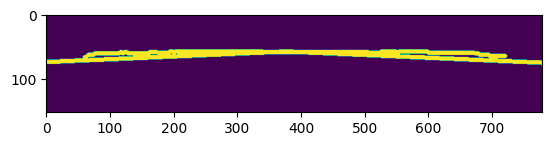

In [324]:
cv2.circle(blank, (int(yc),int(xc)), int(r), (255), 6)
plt.imshow(blank)

In [287]:
if xc<0:
#     mask = cv2.rotate(mask,cv2.ROTATE_180)
#     roi = cv2.rotate(roi,cv2.ROTATE_180)
    x = int(r - w/2)
    y = 2*r-h
    x2 = x+w
    y2 = 2*r
else:
    x = int(r - w/2)
    y = 0
    x2 = x+w
    y2 = h

Text(0.5, 1.0, 'color')

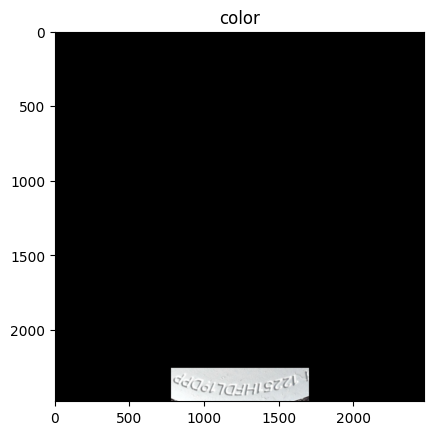

In [288]:
blank = np.zeros((r*2,r*2,3))
blank = blank.astype(np.uint8)
blank[y:y2,x:x2]= roi

plt.imshow(blank)
plt.title("color")

Text(0.5, 1.0, 'color')

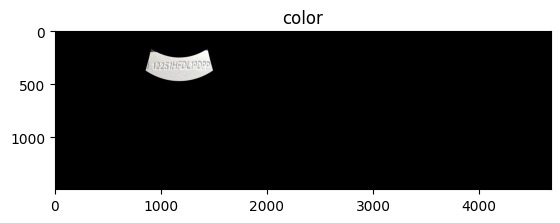

In [289]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
polar_img = cv2.warpPolar(blank,(0,0),(r,r),r+R_OFFSET,flags)
out = polar_img.transpose(1,0,2)[::-1]
plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))
plt.title('color')

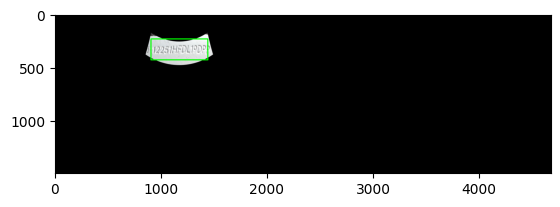

In [290]:
gray = cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, 0)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)
    
cnt_max = contours[np.argmax(areas)]

img = out.copy()
xr,yr,w,h = cv2.boundingRect(cnt_max)
cv2.rectangle(img,(xr+SHRINK,yr+SHRINK),(xr+w-SHRINK,yr+h-SHRINK),(0,255,0),10)
plt.imshow(img)

(1489, 4678, 3)


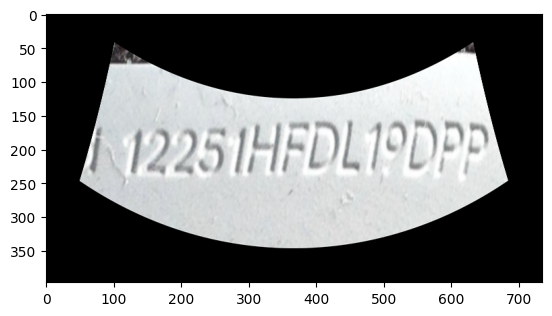

In [291]:
x0=xr-padding
y0=yr-padding
x1=xr+w+padding
y1=yr+h+padding

out2 = out[y0:y1,x0:x1]
print(out.shape)
plt.imshow(out2)